# Libraries

In [138]:
#Import Libraries
import torch
from torch import nn, optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Data Loading

In [139]:
#Data loading
batch_size = 12
train_data = datasets.MNIST('./datasets', train = True, download = True, transform = transforms.ToTensor())
test_data = datasets.MNIST('./datasets', train = False, download = True, transform = transforms.ToTensor())
train_loader = torch.utils.data.DataLoader(train_data, batch_size = batch_size, shuffle = True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size = batch_size)
print(len(train_data))
print(len(test_data))

60000
10000


# Displaying MNIST Sample image

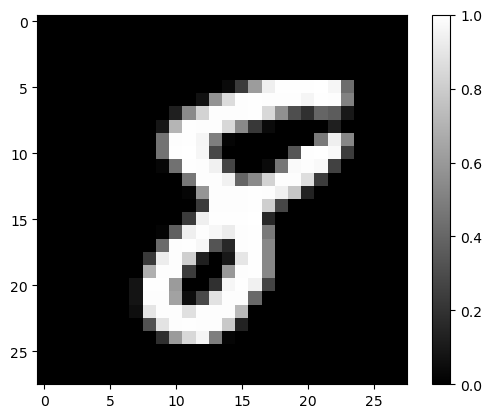

In [140]:
def imshow(img, colorbar=False):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1,2,0)), cmap='gray')
    if colorbar:
        plt.colorbar()
    plt.show()
x, _=train_data[777]
imshow(x, colorbar = True) 

# Large-scale Model

In [141]:
# Large scale model
class MLP_Large(nn.Module):
    def __init__(self):
        super().__init__()

        self.in_dim = 28*28
        self.out_dim = 10

        self.fc1 = nn.Linear(self.in_dim, 512)
        self.fc2 = nn.Linear(512,256)
        self.fc3 = nn.Linear(256,128)
        self.fc4 = nn.Linear(128,64)
        self.fc5 = nn.Linear(64, self.out_dim)
    def forward(self,x):
        x = F.relu(self.fc1(x.view(-1, self.in_dim)))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = self.fc5(x)

        return x

# Training dataset using Large-scale Model

In [142]:
#Training dataset using Large scale model
model1 = MLP_Large()
criterion = nn.CrossEntropyLoss() # loss function으로 CrossEntropyLoss 설정
optimizer = optim.SGD(model1.parameters(), lr = 0.01) #모델의 학습을 위해 SGD optimizer 설정 학습률:0.01
train_losses_1 = [] # training loss 저장 리스트
for epoch in range(5):
    running_loss = 0.0
    cost = 0.0
    for i,data in enumerate(train_loader, 0): #학습 데이터를 배치 단위로 가져옴 
        inputs, labels = data
        model1.zero_grad()  #모델의 기울기 초기화 

        outputs = model1(inputs) #모델에 inputs를 넣어 예측 결과 생성 
        loss = criterion(outputs, labels) #모델의 예측 결과 outputs와 labels를 비교해 loss 계산
        loss.backward() # loss를 기준으로 gradient 계산
        optimizer.step() # 계산된 gradient 사용해 loss function 업데이트 
        cost += loss.item()
        running_loss += loss.item()
        if (i+1) % 2000 ==0: # 2000번째 배치마다 손실을 출력
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0
    epoch_loss = cost / len(train_loader) #에포크 끝날때마다 평균 손실 저장
    train_losses_1.append(epoch_loss)
    
print('Finished Training')  

[1,  2000] loss: 2.181
[1,  4000] loss: 0.670
[2,  2000] loss: 0.309
[2,  4000] loss: 0.230
[3,  2000] loss: 0.162
[3,  4000] loss: 0.146
[4,  2000] loss: 0.108
[4,  4000] loss: 0.104
[5,  2000] loss: 0.077
[5,  4000] loss: 0.079
Finished Training


# Training loss graph(Large-scale model)

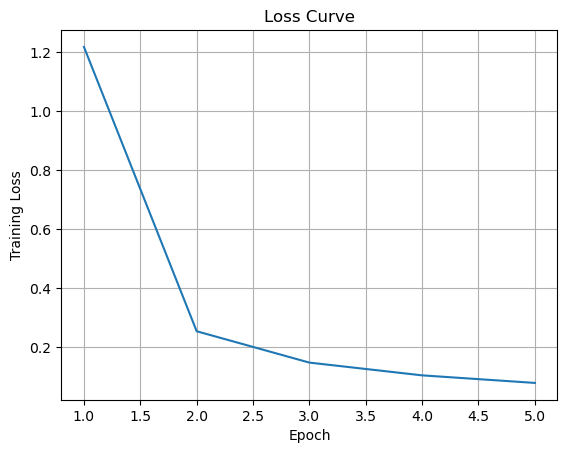

In [143]:
#PLOT
plt.plot(range(1, len(train_losses_1)+1), train_losses_1)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Loss Curve')
plt.grid()
plt.show()

# Test 12 data and show results

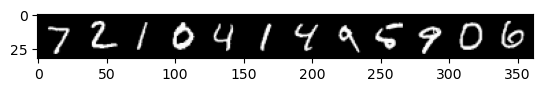

GroundTruth
    7    2    1    0    4    1    4    9    5    9    0    6
Prediction
    7    2    1    0    4    1    4    9    5    9    0    6


In [144]:
images, labels = next(iter(test_loader))

imshow(torchvision.utils.make_grid(images, nrow = batch_size))
print('GroundTruth')
print("  "+'  '.join('%3s' %label.item() for label in labels))

outputs = model1(images)
_, predicted = torch.max(outputs,1)
print("Prediction")
print("  "+'  '.join('%3s' %label.item() for label in predicted))

# Test Accuracy

In [145]:
n_predict = 0
n_correct = 0

for data in test_loader:
    inputs, labels = data
    outputs = model1(inputs)
    _, predicted = torch.max(outputs, 1)

    n_predict += len(predicted)
    n_correct += (labels == predicted).sum()

print(f"{n_correct}/{n_predict}")
print(f"Accuracy: {n_correct/n_predict:.3f}")

9732/10000
Accuracy: 0.973


# Medium-scale Model

In [146]:
# Medium scale model
class MLP_Medium(nn.Module):
    def __init__(self):
        super().__init__()

        self.in_dim = 28*28
        self.out_dim = 10

        self.fc1 = nn.Linear(self.in_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, self.out_dim)
        
    def forward(self,x):
        x = F.relu(self.fc1(x.view(-1, self.in_dim)))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

# Training dataset using Medium-scale Model

In [147]:
#Training dataset using Large scale model
model2 = MLP_Medium()
criterion = nn.CrossEntropyLoss() # loss function으로 CrossEntropyLoss 설정
optimizer = optim.SGD(model2.parameters(), lr = 0.01) #모델의 학습을 위해 SGD optimizer 설정 학습률:0.01
train_losses_2 = [] # training loss 저장 리스트
for epoch in range(5):
    running_loss = 0.0
    cost = 0.0
    for i,data in enumerate(train_loader, 0): #학습 데이터를 배치 단위로 가져옴 
        inputs, labels = data
        model2.zero_grad()  #모델의 기울기 초기화 

        outputs = model2(inputs) #모델에 inputs를 넣어 예측 결과 생성 
        loss = criterion(outputs, labels) #모델의 예측 결과 outputs와 labels를 비교해 loss 계산
        loss.backward() # loss를 기준으로 gradient 계산
        optimizer.step() # 계산된 gradient 사용해 loss function 업데이트 
        cost += loss.item()
        running_loss += loss.item()
        if (i+1) % 2000 ==0: # 2000번째 배치마다 손실을 출력
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0
    epoch_loss = cost / len(train_loader) #에포크 끝날때마다 평균 손실 저장
    train_losses_2.append(epoch_loss)
    
print('Finished Training')  

[1,  2000] loss: 1.100
[1,  4000] loss: 0.374
[2,  2000] loss: 0.287
[2,  4000] loss: 0.255
[3,  2000] loss: 0.208
[3,  4000] loss: 0.186
[4,  2000] loss: 0.161
[4,  4000] loss: 0.148
[5,  2000] loss: 0.132
[5,  4000] loss: 0.117
Finished Training


# Training loss graph(Middle-scale Model)

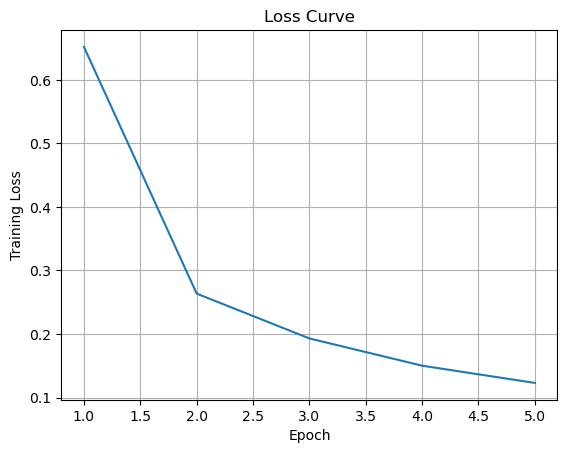

In [148]:
#PLOT
plt.plot(range(1, len(train_losses_2)+1), train_losses_2)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Loss Curve')
plt.grid()
plt.show()

# Test 12 data and show results

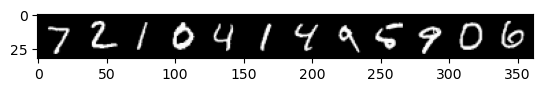

GroundTruth
    7    2    1    0    4    1    4    9    5    9    0    6
Prediction
    7    2    1    0    4    1    4    9    6    9    0    6


In [149]:
images, labels = next(iter(test_loader))

imshow(torchvision.utils.make_grid(images, nrow = batch_size))
print('GroundTruth')
print("  "+'  '.join('%3s' %label.item() for label in labels))

outputs = model2(images)
_, predicted = torch.max(outputs,1)
print("Prediction")
print("  "+'  '.join('%3s' %label.item() for label in predicted))

# Test Accuracy

In [150]:
n_predict = 0
n_correct = 0

for data in test_loader:
    inputs, labels = data
    outputs = model2(inputs)
    _, predicted = torch.max(outputs, 1)

    n_predict += len(predicted)
    n_correct += (labels == predicted).sum()

print(f"{n_correct}/{n_predict}")
print(f"Accuracy: {n_correct/n_predict:.3f}")

9645/10000
Accuracy: 0.965


# Small-scale Model

In [151]:
# Small scale model
class MLP_Small(nn.Module):
    def __init__(self):
        super().__init__()

        self.in_dim = 28*28
        self.out_dim = 10

        self.fc1 = nn.Linear(self.in_dim, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, self.out_dim)
        
    def forward(self,x):
        x = F.relu(self.fc1(x.view(-1, self.in_dim)))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

# Training dataset using Small-scale Model

In [152]:
#Training dataset using Large scale model
model3 = MLP_Small()
criterion = nn.CrossEntropyLoss() # loss function으로 CrossEntropyLoss 설정
optimizer = optim.SGD(model3.parameters(), lr = 0.01) #모델의 학습을 위해 SGD optimizer 설정 학습률:0.01
train_losses_3 = [] # training loss 저장 리스트
for epoch in range(5):
    running_loss = 0.0
    cost = 0.0
    for i,data in enumerate(train_loader, 0): #학습 데이터를 배치 단위로 가져옴 
        inputs, labels = data
        model3.zero_grad()  #모델의 기울기 초기화 

        outputs = model3(inputs) #모델에 inputs를 넣어 예측 결과 생성 
        loss = criterion(outputs, labels) #모델의 예측 결과 outputs와 labels를 비교해 loss 계산
        loss.backward() # loss를 기준으로 gradient 계산
        optimizer.step() # 계산된 gradient 사용해 loss function 업데이트 
        cost += loss.item()
        running_loss += loss.item()
        if (i+1) % 2000 ==0: # 2000번째 배치마다 손실을 출력
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0
    epoch_loss = cost / len(train_loader) #에포크 끝날때마다 평균 손실 저장
    train_losses_3.append(epoch_loss)
    
print('Finished Training')  

[1,  2000] loss: 1.401
[1,  4000] loss: 0.516
[2,  2000] loss: 0.367
[2,  4000] loss: 0.345
[3,  2000] loss: 0.298
[3,  4000] loss: 0.273
[4,  2000] loss: 0.243
[4,  4000] loss: 0.230
[5,  2000] loss: 0.221
[5,  4000] loss: 0.209
Finished Training


# Training loss graph(Small-scale Model)

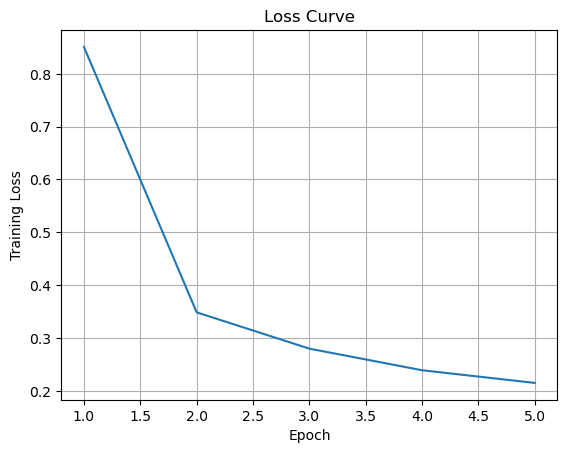

In [153]:
#PLOT
plt.plot(range(1, len(train_losses_3)+1), train_losses_3)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Loss Curve')
plt.grid()
plt.show()

# Test 12 data and show results

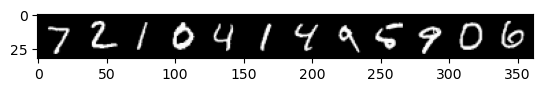

GroundTruth
    7    2    1    0    4    1    4    9    5    9    0    6
Prediction
    7    2    1    0    4    1    4    9    6    9    0    6


In [154]:
images, labels = next(iter(test_loader))

imshow(torchvision.utils.make_grid(images, nrow = batch_size))
print('GroundTruth')
print("  "+'  '.join('%3s' %label.item() for label in labels))

outputs = model3(images)
_, predicted = torch.max(outputs,1)
print("Prediction")
print("  "+'  '.join('%3s' %label.item() for label in predicted))

# Test Accuracy

In [155]:
n_predict = 0
n_correct = 0

for data in test_loader:
    inputs, labels = data
    outputs = model3(inputs)
    _, predicted = torch.max(outputs, 1)

    n_predict += len(predicted)
    n_correct += (labels == predicted).sum()

print(f"{n_correct}/{n_predict}")
print(f"Accuracy: {n_correct/n_predict:.3f}")

9415/10000
Accuracy: 0.942


# Large-scale model with Quantization

In [156]:
#Pytorch 공식 이용해서 Dynamic Quantization 적용 
model1_quant8 = torch.ao.quantization.quantize_dynamic(
    model1,  #학습 완료된 모델
    {torch.nn.Linear}, #Linear 계층만 양자화 
    dtype=torch.qint8 #8비트 정수 양자화
)

# Test 12 data and show results

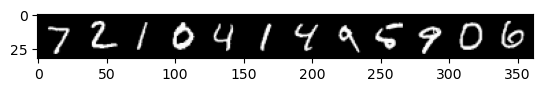

GroundTruth
    7    2    1    0    4    1    4    9    5    9    0    6
Prediction
    7    2    1    0    4    1    4    9    5    9    0    6


In [157]:
images, labels = next(iter(test_loader))

imshow(torchvision.utils.make_grid(images, nrow = batch_size))
print('GroundTruth')
print("  "+'  '.join('%3s' %label.item() for label in labels))

outputs = model1_quant8(images)
_, predicted = torch.max(outputs,1)
print("Prediction")
print("  "+'  '.join('%3s' %label.item() for label in predicted))

# Test Accuracy

In [158]:
n_predict = 0
n_correct = 0

for data in test_loader:
    inputs, labels = data
    outputs = model1_quant8(inputs)
    _, predicted = torch.max(outputs, 1)

    n_predict += len(predicted)
    n_correct += (labels == predicted).sum()

print(f"{n_correct}/{n_predict}")
print(f"Accuracy: {n_correct/n_predict:.3f}")

9732/10000
Accuracy: 0.973


# Three Loss graph

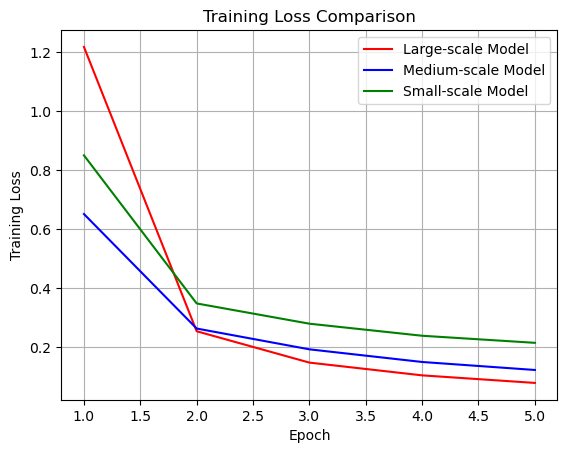

In [159]:
plt.plot(range(1, len(train_losses_1)+1), train_losses_1, label='Large-scale Model', color='red')
plt.plot(range(1, len(train_losses_2)+1), train_losses_2, label='Medium-scale Model', color='blue')
plt.plot(range(1, len(train_losses_3)+1), train_losses_3, label='Small-scale Model', color='green')

plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid()
plt.show()